In [ ]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

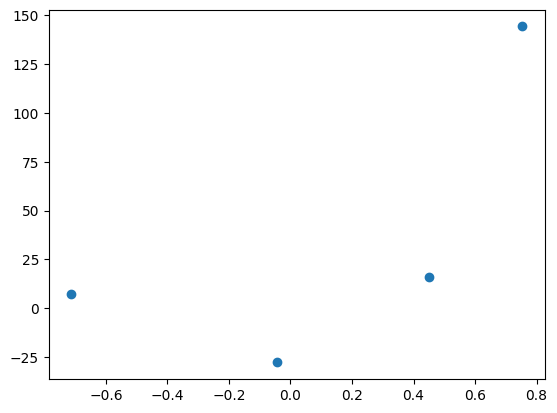

In [ ]:
x,y=make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)
plt.scatter(x,y)

In [ ]:
#lets apply OLS
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x,y)

LinearRegression()

In [ ]:
reg.coef_

array([78.35063668])

In [ ]:
reg.intercept_

np.float64(26.15963284313262)

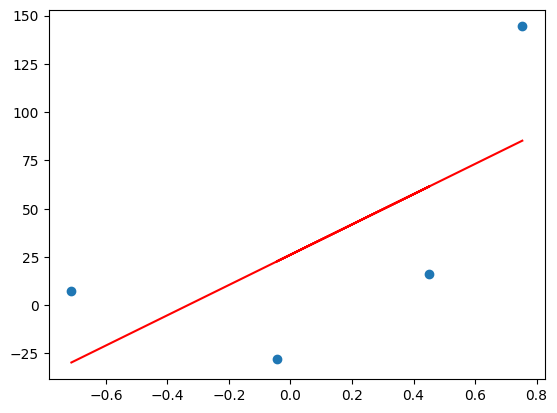

In [ ]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red')

In [ ]:
# Let's apply gradient descent assuming the slope is constant, m is equal to 78.35
#  And let's assume the starting value of intercept b is equal to zero.
y_pred=((78.35*x)+100).reshape(4)

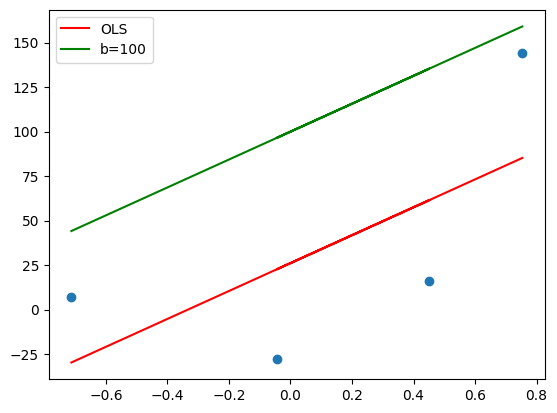

In [ ]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred,color='green',label='b=100')
plt.legend()
plt.show()

In [ ]:
m=78.35
b=100

loss_slope=-2* np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(590.7223659179078)

In [ ]:
# Let's take the learning rate =0.1
lr=0.1
step_size=loss_slope*lr
step_size

np.float64(59.072236591790784)

In [ ]:
#Calculating new interceptors
b=b-step_size
b

np.float64(40.927763408209216)

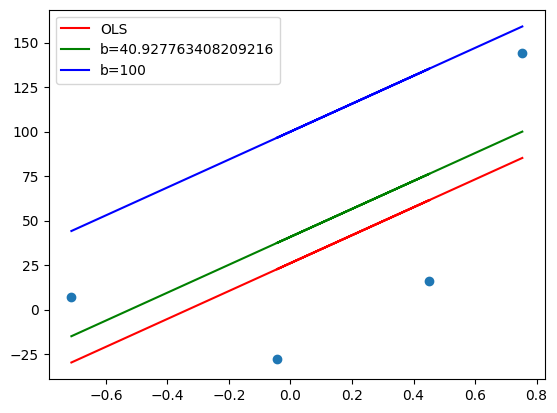

In [ ]:
y_pred1=((78.38*x)+b).reshape(4)
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred1,color='green',label='b={}'.format(b))
plt.plot(x,y_pred,color='blue',label='b=100')
plt.legend()
plt.show()

In [ ]:
# iteration 2
loss_slope=-2*np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(118.14447318358157)

In [ ]:
step_size=loss_slope*lr
step_size

np.float64(11.814447318358157)

In [ ]:
b=b-step_size
b

np.float64(29.11331608985106)

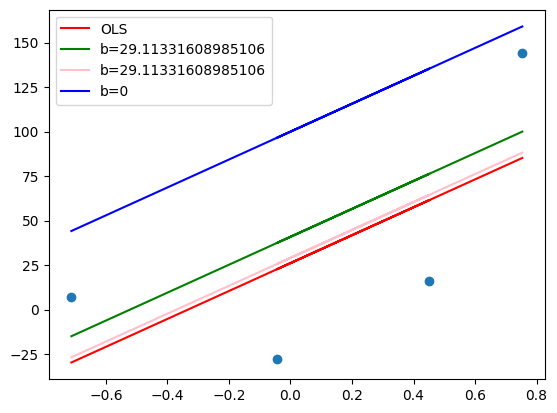

In [ ]:
y_pred2=((78.38*x)+b).reshape(4)
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred1,color='green',label='b={}'.format(b))
plt.plot(x,y_pred2,color='pink',label='b={}'.format(b))
plt.plot(x,y_pred,color='blue',label='b=0')
plt.legend()
plt.show()

In [ ]:
# iteration 3
loss_slope=-2*np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(23.62889463671634)

In [ ]:
step_size=loss_slope*lr
step_size

np.float64(2.362889463671634)

In [ ]:
b=b-step_size
b

np.float64(26.750426626179426)

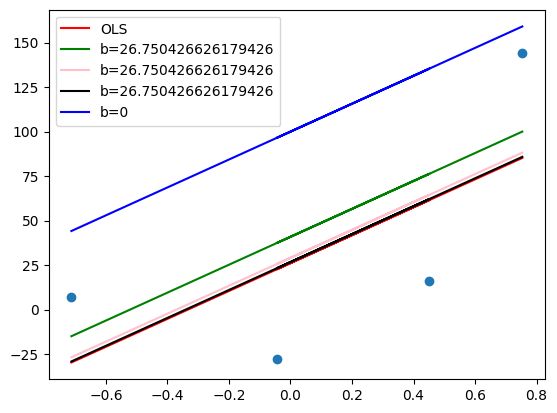

In [ ]:
y_pred3=((78.38*x)+b).reshape(4)
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red',label='OLS')
plt.plot(x,y_pred1,color='green',label='b={}'.format(b))
plt.plot(x,y_pred2,color='pink',label='b={}'.format(b))
plt.plot(x,y_pred3,color='black',label='b={}'.format(b))
plt.plot(x,y_pred,color='blue',label='b=0')
plt.legend()
plt.show()

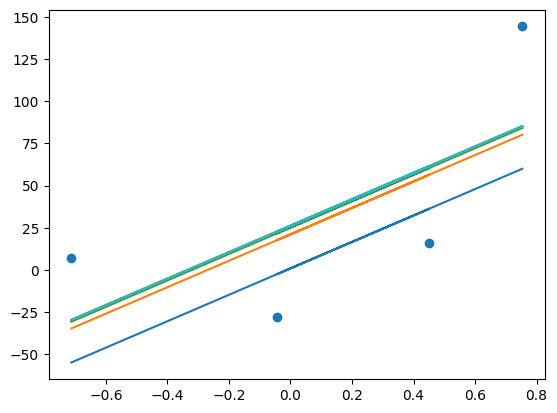

In [ ]:
# This can be done using loop
b=-100
m=78.35
lr=0.1

epochs=10

for i in range(epochs):
  loss_slope=-2*np.sum(y-m*x.ravel()-b)
  b=b-(lr*loss_slope)

  y_pred4=m*x+b

  plt.plot(x,y_pred4)
plt.scatter(x,y)

# MY_Class

In [ ]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

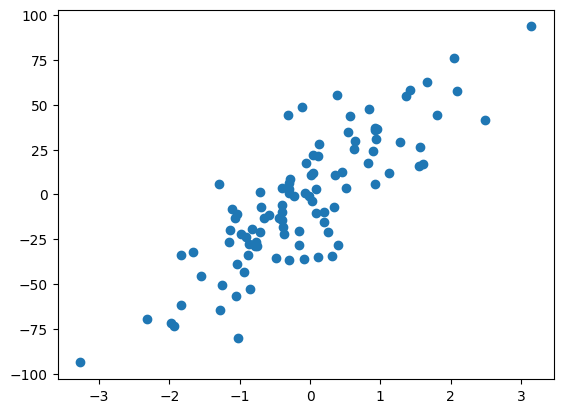

In [ ]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)
plt.scatter(x,y)

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [ ]:
lr.fit(x,y)
lr.coef_

array([28.04226782])

In [ ]:
lr.intercept_

np.float64(-0.5523026101213713)

In [ ]:
class GDRegressor:
  def __init__(self, learning_rate, epochs):
    self.m=34.289
    self.b=0.381
    self.lr=learning_rate
    self.epochs=epochs

  def fit(self,x,y):
    for i in range(self.epochs):
      loss_slope=-2*np.sum(y-self.m*x.ravel()-self.b)
      self.b=b-(lr*loss_slope)
      y_pred4=m*x+b
    print(self.b)

In [ ]:
gd=GDRegressor(0.1,10)

In [ ]:
# gd.fit(x,y)

## Gradient Descent with calculating m and b both

In [ ]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

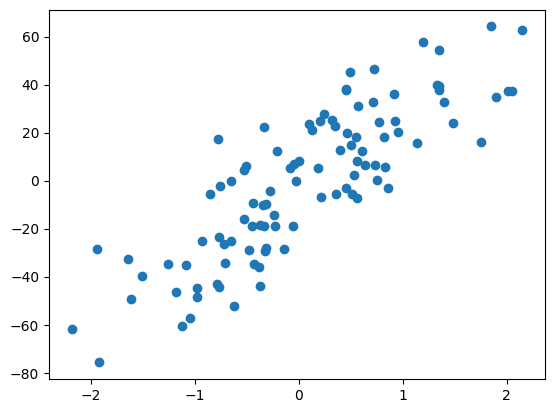

In [ ]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)
plt.scatter(x,y)

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [ ]:
lr.fit(x,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [ ]:
np.mean(cross_val_score(lr,x,y,scoring="r2",cv=10))

np.float64(0.6375011587464419)

In [ ]:
class GDRegressor:
  def __init__(self, learning_rate, epochs):
    self.m=100
    self.b=-120
    self.lr=learning_rate
    self.epochs=epochs

  def fit(self,x,y):
    for i in range(self.epochs):
      loss_slope_b=-2*np.sum(y-self.m*x.ravel()-self.b)
      loss_slope_m=-2*np.sum(x.ravel()*(y-self.m*x.ravel()-self.b))
      self.b=self.b-(self.lr*loss_slope_b)
      self.m=self.m-(self.lr*loss_slope_m)
      y_pred4=m*x+b
    print(self.b)
    print(self.m)

  def predict(self,x):
    return self.m*x+self.b

In [ ]:
gd=GDRegressor(0.001,100)

In [ ]:
gd.fit(x,y)

-2.2947448944994893
27.828091872608653


In [ ]:
gd.predict(x)

array([[-22.11921769],
       [-14.45967436],
       [-14.92180785],
       [ 24.22071289],
       [  4.32438488],
       [ 21.67112435],
       [ -9.06605019],
       [  2.851948  ],
       [-22.35879005],
       [-14.25796038],
       [ 53.78500537],
       [  8.75972323],
       [  3.48793408],
       [ -8.76271341],
       [-23.68416824],
       [ 10.31579463],
       [ 15.5120051 ],
       [  7.71035286],
       [-47.24011768],
       [ 46.38331635],
       [-24.25080397],
       [-16.54175657],
       [-28.12854285],
       [ 57.54630988],
       [ -8.06489135],
       [-47.90758693],
       [-11.71784478],
       [-11.25883162],
       [-15.69039288],
       [-16.85340673],
       [ 17.79616505],
       [ 19.01909815],
       [ 10.32476716],
       [-37.40283105],
       [-63.15798965],
       [-35.28268842],
       [  3.75651986],
       [ 34.72543668],
       [-32.54893408],
       [ 13.35192552],
       [-44.39433775],
       [ -2.36122692],
       [-10.03469777],
       [ 10